<a href="https://colab.research.google.com/github/Prashkov1ch/python-ai-Prashkovich-Anna/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_Lab05_Economists_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 5 (экономисты): Pandas — объединение, группировка, сводные, временные ряды

**Ограничения:** упор на `pandas` (numpy допускается).

**Цель:** отработать:
- объединение наборов данных (merge/join/concat),
- агрегирование и группировку (groupby),
- сводные таблицы (pivot_table),
- временные ряды (DatetimeIndex/resample).

In [2]:
import re
from openpyxl import load_workbook
import numpy as np
import os
from google.colab import drive

# 1. Монтируем диск (если уже смонтирован, просто игнорируем ошибку)
try:
    drive.mount('/content/drive')
except:
    pass

PATH = '/content/drive/MyDrive/цифровая кафедра/'  # Проверь, что имя папки верное!
os.chdir(PATH)

FILES = ['Копия 1 Атомэнергопром.xlsx', 'Копия 2 Аэрофлот.xlsx', 'Копия 3 Газпром_петрозаводск.xlsx',
         'Копия 4 Лукойл.xlsx', 'Копия 5 Роснефть.xlsx', 'Копия 6 Самолет.xlsx',
         'Копия 7 Славмо.xlsx', 'Копия 8 Строительная_компания_Век.xlsx',
         'Копия 9 ТГК_1.xlsx', 'Копия 10 ТНС_ЭНЭРГО_Карелия.xlsx']

# --- ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ ДЛЯ ОЧИСТКИ ЧИСЕЛ ---
def clean_number(value):
    """
    Превращает значение из Excel в число float.
    Удаляет пробелы из строк вида '1 000 000'.
    Если значение пустое — возвращает np.nan.
    """
    if value is None:
        return np.nan
    # Превращаем в строку и убираем все пробелы
    s = str(value).replace(' ', '')
    try:
        return float(s)
    except:
        return np.nan

def org_info(xlsx_name: str):
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Сведения об организации"]
    full = str(ws.cell(6, 13).value)
    okved = str(ws.cell(15, 13).value)
    addr = str(ws.cell(16, 13).value)
    m = re.search(r"(?P<zip>\d{6}),\s*(?P<city>[^,]+?)\s+г,", addr)
    return {
        "file": xlsx_name,
        "company": full,
        "okved": okved,
        "zip": m.group("zip") if m else None,
        "city": m.group("city").strip() if m else None,
    }

def parse_balance_years(xlsx_name: str):
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Бухгалтерский баланс"]
    res = {}
    for r in range(6, 400):
        code = ws.cell(r, 14).value
        if code is None:
            continue
        code = str(code).strip()
        if not re.fullmatch(r"\d{4}", code):
            continue
        v23 = ws.cell(r, 17).value
        v22 = ws.cell(r, 23).value
        v21 = ws.cell(r, 30).value
        # ИСПРАВЛЕНО: используем clean_number для очистки данных
        res[code] = {2021: clean_number(v21), 2022: clean_number(v22), 2023: clean_number(v23)}
    return res

def parse_financial(xlsx_name: str):
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Отчет о финансовых результатах"]
    res = {}
    for r in range(6, 200):
        code = ws.cell(r, 16).value
        if code is None:
            continue
        code = str(code).strip()
        if not re.fullmatch(r"\d{4}", code):
            continue
        v23 = ws.cell(r, 21).value
        v22 = ws.cell(r, 27).value
        # ИСПРАВЛЕНО: используем clean_number для очистки данных
        res[code] = {2022: clean_number(v22), 2023: clean_number(v23)}
    return res

org_df = pd.DataFrame([org_info(fn) for fn in FILES])

fin_rows = []
bal_rows = []
for fn in FILES:
    fin = parse_financial(fn)
    bal = parse_balance_years(fn)
    company = org_df.loc[org_df["file"]==fn, "company"].iloc[0]

    for y in [2022, 2023]:
        fin_rows.append({
            "file": fn,
            "company": company,
            "year": y,
            "revenue_2110": fin.get("2110", {}).get(y, np.nan),
            "net_profit_2400": fin.get("2400", {}).get(y, np.nan),
        })

    for y in [2021, 2022, 2023]:
        bal_rows.append({
            "file": fn,
            "company": company,
            "year": y,
            "assets_1600": bal.get("1600", {}).get(y, np.nan),
            "equity_1300": bal.get("1300", {}).get(y, np.nan),
        })

fin_df = pd.DataFrame(fin_rows)
bal_df = pd.DataFrame(bal_rows)

print("✅ Данные успешно загружены и очищены!")
print(f"org_df: {org_df.shape}, fin_df: {fin_df.shape}, bal_df: {bal_df.shape}")
display(org_df.head(3))
display(fin_df.head(3))
display(bal_df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


✅ Данные успешно загружены и очищены!
org_df: (10, 5), fin_df: (20, 5), bal_df: (30, 5)


,file,company,okved,zip,city
0,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",62.09,119017,Москва
1,Копия 2 Аэрофлот.xlsx,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",51.10.1,119019,Москва
2,Копия 3 Газпром_петрозаводск.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",35.22,None,None


,file,company,year,revenue_2110,net_profit_2400
0,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2022,1851540.0,NaN
1,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2023,10667978.0,91493932.0
2,Копия 2 Аэрофлот.xlsx,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",2022,332747813.0,NaN


,file,company,year,assets_1600,equity_1300
0,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2021,2.214126e+09,1.617792e+09
1,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2022,2.222861e+09,1.464189e+09
2,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2023,2.275888e+09,1.516195e+09


### Задание 1
Объедините `fin_df` и `org_df` по столбцу `file` (left join).  
Покажите 5 строк результата и список получившихся колонок.

In [3]:
# Объединение fin_df и org_df по столбцу file (left join)
merged_df = fin_df.merge(org_df, on='file', how='left')

# Показать 5 строк результата
print("Первые 5 строк объединённой таблицы:")
display(merged_df.head(5))

# Список получившихся колонок
print("\nСписок колонок:")
print(list(merged_df.columns))

Первые 5 строк объединённой таблицы:


,file,company_x,year,revenue_2110,net_profit_2400,company_y,okved,zip,city
0,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2022,1851540.0,NaN,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",62.09,119017,Москва
1,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2023,10667978.0,91493932.0,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",62.09,119017,Москва
2,Копия 2 Аэрофлот.xlsx,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",2022,332747813.0,NaN,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",51.10.1,119019,Москва
3,Копия 2 Аэрофлот.xlsx,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",2023,497511315.0,NaN,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",51.10.1,119019,Москва
4,Копия 3 Газпром_петрозаводск.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",2022,NaN,NaN,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",35.22,None,None



Список колонок:
['file', 'company_x', 'year', 'revenue_2110', 'net_profit_2400', 'company_y', 'okved', 'zip', 'city']


### Задание 2
Посчитайте агрегаты по `year`: суммарная выручка и суммарная чистая прибыль.  
Используйте `groupby` + `agg`.

In [4]:
# Агрегаты по year: суммарная выручка и суммарная чистая прибыль
aggregates = fin_df.groupby('year').agg({
    'revenue_2110': 'sum',
    'net_profit_2400': 'sum'
}).reset_index()

print("Агрегаты по годам:")
display(aggregates)

Агрегаты по годам:


,year,revenue_2110,net_profit_2400
0,2022,3.313166e+09,805315282.0
1,2023,3.382181e+09,846814937.0


### Задание 3
Добавьте в `fin_df` столбец `margin` = profit/revenue и посчитайте среднюю маржу по годам.  
Игнорируйте деление на 0/NaN.

In [5]:
# Добавить столбец margin = profit/revenue
fin_df['margin'] = fin_df['net_profit_2400'] / fin_df['revenue_2110']

# Посчитать среднюю маржу по годам (игнорируя деление на 0/NaN)
avg_margin_by_year = fin_df.groupby('year')['margin'].mean().reset_index()

print("Средняя маржа по годам:")
display(avg_margin_by_year)

# Показать 10 строк с margin
print("\n10 строк с margin:")
display(fin_df[['company', 'year', 'revenue_2110', 'net_profit_2400', 'margin']].head(10))

Средняя маржа по годам:


,year,margin
0,2022,0.898541
1,2023,3.834297



10 строк с margin:


,company,year,revenue_2110,net_profit_2400,margin
0,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2022,1.851540e+06,NaN,NaN
1,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2023,1.066798e+07,91493932.0,8.576502
2,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",2022,3.327478e+08,NaN,NaN
3,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",2023,4.975113e+08,NaN,NaN
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",2022,NaN,NaN,NaN
5,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",2023,NaN,NaN,NaN
6,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""НЕФТЯНАЯ КОМПА...",2022,2.874037e+09,790120077.0,0.274916
7,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""НЕФТЯНАЯ КОМПА...",2023,2.753475e+09,655289456.0,0.237986
8,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",2022,NaN,NaN,NaN
9,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",2023,NaN,NaN,NaN


### Задание 4
Сделайте сводную таблицу (pivot_table): строки — company, колонки — year, значения — revenue_2110.  
Заполните пропуски нулями.

In [6]:
# Сводная таблица: строки — company, колонки — year, значения — revenue_2110
revenue_pivot = fin_df.pivot_table(
    index='company',
    columns='year',
    values='revenue_2110',
    fill_value=0
)

print("Сводная таблица выручки по компаниям и годам:")
display(revenue_pivot.head(5))
print(f"\nКолонки: {list(revenue_pivot.columns)}")
print(f"Индекс: {revenue_pivot.index.name}")

Сводная таблица выручки по компаниям и годам:


year,2022,2023
company,,
"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫЙ КОМПЛЕКС""",1851540.0,10667978.0
"АКЦИОНЕРНОЕ ОБЩЕСТВО ""СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТРОЙЩИК ""СТРОИТЕЛЬНАЯ КОМПАНИЯ ""ВЕК""",644115.0,1318962.0
"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕРРИТОРИАЛЬНАЯ ГЕНЕРИРУЮЩАЯ КОМПАНИЯ №1""",98823872.0,101697792.0
"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИЙСКИЕ АВИАЛИНИИ""",332747813.0,497511315.0
"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГРУППА КОМПАНИЙ ""САМОЛЕТ""",3209771.0,6841987.0



Колонки: [2022, 2023]
Индекс: company


### Задание 5
По сводной таблице выручки посчитайте темп роста 2023 к 2022: `(2023-2022)/2022`.  
Покажите топ-5 по росту.

In [7]:
# Темп роста 2023 к 2022: (2023-2022)/2022
# Проверяем, что колонки 2022 и 2023 существуют
if 2022 in revenue_pivot.columns and 2023 in revenue_pivot.columns:
    growth_rate = (revenue_pivot[2023] - revenue_pivot[2022]) / revenue_pivot[2022]

    # Заменяем бесконечные значения на NaN (деление на 0)
    growth_rate = growth_rate.replace([np.inf, -np.inf], np.nan)

    # Топ-5 по росту
    top5_growth = growth_rate.nlargest(5)

    print("Топ-5 компаний по темпу роста выручки (2023 к 2022):")
    print("=" * 60)
    display(top5_growth)

    # С подробностями
    print("\nПодробно:")
    for company in top5_growth.index:
        rev_2022 = revenue_pivot.loc[company, 2022]
        rev_2023 = revenue_pivot.loc[company, 2023]
        growth = top5_growth.loc[company]
        print(f"  {company}: {growth:.2%} ({rev_2022:,.0f} → {rev_2023:,.0f})")
else:
    print("Ошибка: колонки 2022 или 2023 не найдены в сводной таблице")

Топ-5 компаний по темпу роста выручки (2023 к 2022):


,0
company,
"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫЙ КОМПЛЕКС""",4.761678
"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГРУППА КОМПАНИЙ ""САМОЛЕТ""",1.131612
"АКЦИОНЕРНОЕ ОБЩЕСТВО ""СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТРОЙЩИК ""СТРОИТЕЛЬНАЯ КОМПАНИЯ ""ВЕК""",1.047712
"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИЙСКИЕ АВИАЛИНИИ""",0.495160
"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕРРИТОРИАЛЬНАЯ ГЕНЕРИРУЮЩАЯ КОМПАНИЯ №1""",0.029081



Подробно:
  АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫЙ КОМПЛЕКС": 476.17% (1,851,540 → 10,667,978)
  ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "ГРУППА КОМПАНИЙ "САМОЛЕТ": 113.16% (3,209,771 → 6,841,987)
  АКЦИОНЕРНОЕ ОБЩЕСТВО "СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТРОЙЩИК "СТРОИТЕЛЬНАЯ КОМПАНИЯ "ВЕК": 104.77% (644,115 → 1,318,962)
  ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙСКИЕ АВИАЛИНИИ": 49.52% (332,747,813 → 497,511,315)
  ПУБЛИЧНОЕ АКЦИОНЕРНОЕ  ОБЩЕСТВО  "ТЕРРИТОРИАЛЬНАЯ  ГЕНЕРИРУЮЩАЯ  КОМПАНИЯ   №1": 2.91% (98,823,872 → 101,697,792)


### Задание 6
Сгруппируйте компании по `okved` и посчитайте среднюю выручку 2023 (по компании).  
(Подсказка: сначала merge, потом groupby.)

In [8]:
# 1. Объединяем fin_df и org_df по столбцу company (или file)
merged_df = fin_df.merge(org_df[['company', 'okved']], on='company', how='left')

# 2. Фильтруем только 2023 год
merged_2023 = merged_df[merged_df['year'] == 2023]

# 3. Группируем по okved и считаем среднюю выручку
avg_revenue_by_okved = merged_2023.groupby('okved')['revenue_2110'].mean().reset_index()
avg_revenue_by_okved.columns = ['okved', 'avg_revenue_2023']

# 4. Сортируем по убыванию средней выручки
avg_revenue_by_okved = avg_revenue_by_okved.sort_values('avg_revenue_2023', ascending=False)

print("Средняя выручка 2023 по кодам ОКВЭД:")
print("=" * 60)
display(avg_revenue_by_okved)

# Дополнительно: количество компаний в каждой группе
company_count = merged_2023.groupby('okved')['company'].nunique().reset_index()
company_count.columns = ['okved', 'company_count']

result = avg_revenue_by_okved.merge(company_count, on='okved')
print("\nС количеством компаний:")
display(result)

Средняя выручка 2023 по кодам ОКВЭД:


,okved,avg_revenue_2023
6,70.10.2,2.753475e+09
4,51.10.1,4.975113e+08
1,35.11,1.016978e+08
5,62.09,1.066798e+07
7,70.22,6.841987e+06
3,41.20,1.318962e+06
0,10.51,NaN
2,35.22,NaN



С количеством компаний:


,okved,avg_revenue_2023,company_count
0,70.10.2,2.753475e+09,1
1,51.10.1,4.975113e+08,1
2,35.11,1.016978e+08,1
3,62.09,1.066798e+07,1
4,70.22,6.841987e+06,1
5,41.20,1.318962e+06,1
6,10.51,NaN,1
7,35.22,NaN,1


### Задание 7
Сделайте `concat`: объедините `fin_df` и `bal_df` по строкам в единый DataFrame `all_df`,  
добавив колонку `table` со значениями 'FIN' и 'BAL'. Покажите 5 строк.

In [9]:
# Задание 7: concat fin_df и bal_df с колонкой table

# Добавляем колонку table в каждый DataFrame
fin_df_labeled = fin_df.copy()
fin_df_labeled['table'] = 'FIN'

bal_df_labeled = bal_df.copy()
bal_df_labeled['table'] = 'BAL'

# Объединяем по строкам с помощью concat
all_df = pd.concat([fin_df_labeled, bal_df_labeled], ignore_index=True)

# Показываем 5 строк результата
print("Объединённый DataFrame (all_df):")
display(all_df.head(5))
print(f"\nРазмер all_df: {all_df.shape}")
print(f"Колонки: {list(all_df.columns)}")

Объединённый DataFrame (all_df):


,file,company,year,revenue_2110,net_profit_2400,margin,table,assets_1600,equity_1300
0,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2022,1851540.0,NaN,NaN,FIN,NaN,NaN
1,Копия 1 Атомэнергопром.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕНН...",2023,10667978.0,91493932.0,8.576502,FIN,NaN,NaN
2,Копия 2 Аэрофлот.xlsx,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",2022,332747813.0,NaN,NaN,FIN,NaN,NaN
3,Копия 2 Аэрофлот.xlsx,"ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИ...",2023,497511315.0,NaN,NaN,FIN,NaN,NaN
4,Копия 3 Газпром_петрозаводск.xlsx,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕН...",2022,NaN,NaN,NaN,FIN,NaN,NaN



Размер all_df: (50, 9)
Колонки: ['file', 'company', 'year', 'revenue_2110', 'net_profit_2400', 'margin', 'table', 'assets_1600', 'equity_1300']


### Задание 8
Сделайте join по индексу:  
1) установите индекс `(company, year)` для fin_df и bal_df;  
2) выполните `.join`, чтобы получить в одной таблице и фин.результаты, и активы/капитал.  
Покажите 6 строк.

In [13]:

fin_indexed = fin_df.set_index(['company', 'year'])
bal_indexed = bal_df.set_index(['company', 'year'])

# Удаляем столбец 'file' из bal_indexed, так как он уже есть в fin_indexed
bal_indexed = bal_indexed.drop(columns=['file'])

# Теперь join без суффиксов
joined_df = fin_indexed.join(bal_indexed, how='inner')

display(joined_df.head(6))

file  \
company                                            year                                
АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫ... 2022  Копия 1 Атомэнергопром.xlsx   
                                                   2022  Копия 1 Атомэнергопром.xlsx   
                                                   2023  Копия 1 Атомэнергопром.xlsx   
                                                   2023  Копия 1 Атомэнергопром.xlsx   
ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙ... 2022        Копия 2 Аэрофлот.xlsx   
                                                   2023        Копия 2 Аэрофлот.xlsx   

                                                         revenue_2110  \
company                                            year                 
АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫ... 2022     1851540.0   
                                                   2022     1851540.0   
                                                   2023    10667978.0   
                                                   2023    10667978.0   
ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙ... 2022   332747813.0   
                                                   2023   497511315.0   

                                                         net_profit_2400  \
company                                            year                    
АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫ... 2022              NaN   
                                                   2022              NaN   
                                                   2023       91493932.0   
                                                   2023       91493932.0   
ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙ... 2022              NaN   
                                                   2023              NaN   

                                                           margin  \
company                                            year             
АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫ... 2022       NaN   
                                                   2022       NaN   
                                                   2023  8.576502   
                                                   2023  8.576502   
ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙ... 2022       NaN   
                                                   2023       NaN   

                                                          assets_1600  \
company                                            year                 
АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫ... 2022  2.222861e+09   
                                                   2022  2.222861e+09   
                                                   2023  2.275888e+09   
                                                   2023  2.275888e+09   
ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙ... 2022  7.847067e+08   
                                                   2023  9.342681e+08   

                                                          equity_1300  
company                                            year                
АКЦИОНЕРНОЕ ОБЩЕСТВО "АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫ... 2022  1.464189e+09  
                                                   2022  1.464189e+09  
                                                   2023  1.516195e+09  
                                                   2023  1.516195e+09  
ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "АЭРОФЛОТ-РОССИЙ... 2022           NaN  
                                                   2023           NaN

### Задание 9
Постройте временной ряд активов (assets_1600) по всем компаниям: суммарно по годам 2021–2023.  
Сделайте `DatetimeIndex` по 31 декабря соответствующего года и примените `resample('A')`.

Временной ряд суммарных активов (2021-2023):


/tmp/ipykernel_219/3150750119.py:11: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  assets_resampled = assets_series.resample('A').sum()


,total_assets
2021-12-31,7.714746e+09
2022-12-31,7.822292e+09
2023-12-31,8.590263e+09


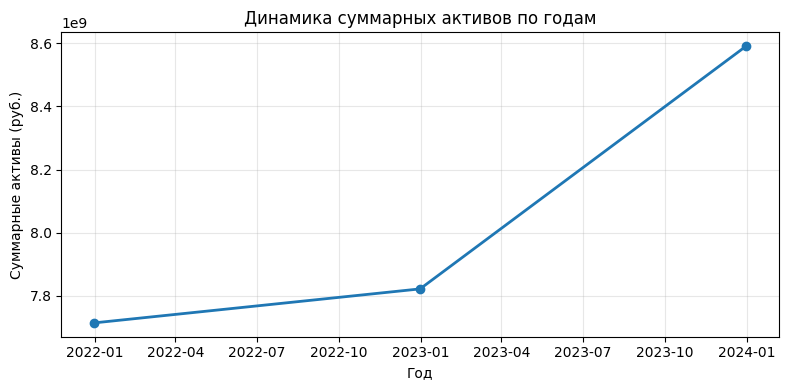

In [14]:
# Задание 9: Временной ряд активов с DatetimeIndex и resample

# 1. Группируем по году и суммируем активы по всем компаниям
assets_by_year = bal_df.groupby('year')['assets_1600'].sum()

# 2. Создаём DatetimeIndex по 31 декабря каждого года
dates = pd.to_datetime([f'{year}-12-31' for year in assets_by_year.index])
assets_series = pd.Series(assets_by_year.values, index=dates, name='total_assets')

# 3. Применяем resample('A') - агрегация по концу года
assets_resampled = assets_series.resample('A').sum()

# Показываем результат
print("Временной ряд суммарных активов (2021-2023):")
display(assets_resampled)

# Визуализация
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(assets_resampled.index, assets_resampled.values, marker='o', linewidth=2)
plt.xlabel('Год')
plt.ylabel('Суммарные активы (руб.)')
plt.title('Динамика суммарных активов по годам')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Задание 10
Для одной компании постройте временной ряд капитала (equity_1300) по годам 2021–2023.  
Выберите компанию с максимальными активами в 2023 и получите её ряд.

Компания с максимальными активами в 2023: ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "НЕФТЯНАЯ КОМПАНИЯ "ЛУКОЙЛ"

Временной ряд капитала для ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "НЕФТЯНАЯ КОМПАНИЯ "ЛУКОЙЛ":


/tmp/ipykernel_219/2556516959.py:16: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  equity_resampled = equity_series.resample('A').sum()


,equity
2021-12-31,1.024747e+09
2022-12-31,1.265167e+09
2023-12-31,1.308113e+09


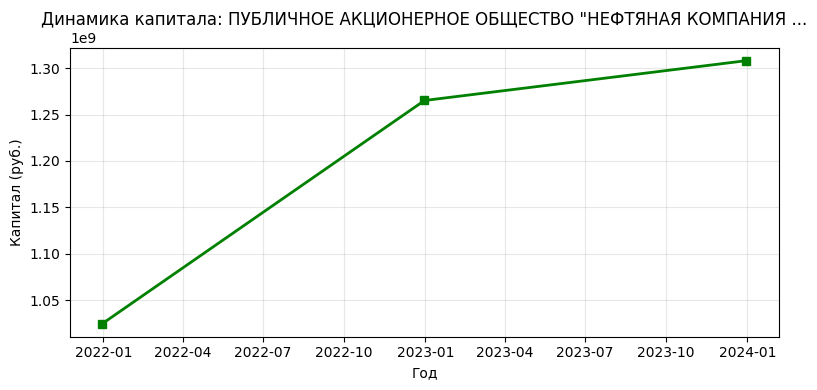

In [15]:
# Задание 10: Временной ряд капитала для компании с максимальными активами 2023

# 1. Находим компанию с максимальными активами в 2023 году
assets_2023 = bal_df[bal_df['year'] == 2023]
max_assets_company = assets_2023.loc[assets_2023['assets_1600'].idxmax(), 'company']
print(f"Компания с максимальными активами в 2023: {max_assets_company}")

# 2. Фильтруем данные по этой компании
company_data = bal_df[bal_df['company'] == max_assets_company].copy()

# 3. Создаём DatetimeIndex по 31 декабря каждого года
dates = pd.to_datetime([f'{year}-12-31' for year in company_data['year']])
equity_series = pd.Series(company_data['equity_1300'].values, index=dates, name='equity')

# 4. Применяем resample('A') для временного ряда
equity_resampled = equity_series.resample('A').sum()

# Показываем результат
print(f"\nВременной ряд капитала для {max_assets_company}:")
display(equity_resampled)

# Визуализация
plt.figure(figsize=(8, 4))
plt.plot(equity_resampled.index, equity_resampled.values, marker='s', linewidth=2, color='green')
plt.xlabel('Год')
plt.ylabel('Капитал (руб.)')
plt.title(f'Динамика капитала: {max_assets_company[:50]}...')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Задание 11
Сделайте сводную таблицу по городам: средняя выручка 2023 (по компаниям), где город извлечён из адреса.  
Используйте merge и pivot_table.

In [16]:
# Задание 11: Сводная таблица по городам — средняя выручка 2023

# 1. Объединяем fin_df с org_df для получения информации о городах
merged_city = fin_df.merge(org_df[['company', 'city']], on='company', how='left')

# 2. Фильтруем данные только за 2023 год
merged_2023 = merged_city[merged_city['year'] == 2023]

# 3. Создаём сводную таблицу: города в строках, средняя выручка
city_revenue_pivot = merged_2023.pivot_table(
    index='city',
    values='revenue_2110',
    aggfunc='mean'
)

# 4. Сортируем по убыванию выручки
city_revenue_pivot = city_revenue_pivot.sort_values('revenue_2110', ascending=False)

# 5. Выводим результат
print("Средняя выручка 2023 по городам:")
print("=" * 60)
display(city_revenue_pivot)

# Дополнительно: количество компаний в каждом городе
city_count = merged_2023.groupby('city')['company'].nunique()
print("\nКоличество компаний по городам:")
display(city_count)

Средняя выручка 2023 по городам:


,revenue_2110
city,
Москва,108036645.4
Санкт-Петербург,101697792.0



Количество компаний по городам:


,company
city,
Москва,2
Санкт-Петербург,1


### Задание 12
Сформируйте «панель» в широком формате: индекс — year, колонки — company, значения — assets_1600.  
Используйте `pivot`. Покажите получившийся DataFrame.

In [18]:
# Задание 12: Панель в широком формате — активы по годам и компаниям

# 1. Используем pivot_table вместо pivot для обработки возможных дублей
# index — year, columns — company, values — assets_1600
# aggfunc='sum' — агрегируем дубли суммированием (можно 'mean', 'first' и т.д.)
assets_panel = bal_df.pivot_table(
    index='year',
    columns='company',
    values='assets_1600',
    aggfunc='sum'
)

# 2. Выводим получившийся DataFrame
print("Панель активов (assets_1600) в широком формате:")
print("=" * 80)
display(assets_panel)

# 3. Дополнительная информация о структуре
print(f"\nРазмер DataFrame: {assets_panel.shape}")
print(f"Индекс (годы): {list(assets_panel.index)}")
print(f"Колонки (компании): {len(assets_panel.columns)}")

Панель активов (assets_1600) в широком формате:


company,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГАЗПРОМ ГАЗОРАСПРЕДЕЛЕНИЕ ПЕТРОЗАВОДСК""","АКЦИОНЕРНОЕ ОБЩЕСТВО ""АТОМНЫЙ ЭНЕРГОПРОМЫШЛЕННЫЙ КОМПЛЕКС""","АКЦИОНЕРНОЕ ОБЩЕСТВО ""СЛАВМО""","АКЦИОНЕРНОЕ ОБЩЕСТВО ""СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТРОЙЩИК ""СТРОИТЕЛЬНАЯ КОМПАНИЯ ""ВЕК""","ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТЕРРИТОРИАЛЬНАЯ ГЕНЕРИРУЮЩАЯ КОМПАНИЯ №1""","ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""АЭРОФЛОТ-РОССИЙСКИЕ АВИАЛИНИИ""","ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""ГРУППА КОМПАНИЙ ""САМОЛЕТ""","ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""НЕФТЯНАЯ КОМПАНИЯ ""ЛУКОЙЛ"""
year,,,,,,,,
2021,0.0,4.428252e+09,0.0,5094949.0,173223373.0,937788555.0,69094977.0,2.101293e+09
2022,0.0,4.445723e+09,0.0,6382638.0,189656095.0,784706739.0,111564026.0,2.284260e+09
2023,0.0,4.551775e+09,0.0,6607975.0,196595132.0,934268135.0,190308363.0,2.710709e+09



Размер DataFrame: (3, 8)
Индекс (годы): [2021, 2022, 2023]
Колонки (компании): 8
